---
jupyter:
  jupytext:
    text_representation:
      extension: .qmd
      format_name: quarto
      format_version: '1.0'
      jupytext_version: 1.19.1
  kernelspec:
    display_name: DL
    language: python
    name: python3
---

<style>
    pre {
        white-space: pre-wrap;
        word-wrap: break-word;
    }
</style>

<div style="display:flex; justify-content:space-around; align-items:center; background-color:#cccccc; padding:5px; border:2px solid #333333;">
    <a href="https://estudios.upct.es/grado/5251/inicio" target="_blank">
    <img src="https://www.upct.es/contenido/universidad/galeria/identidad-2021/logos/logos-upct/marca-upct/marca-principal/horizontal/azul.png" alt="UPCT" style="height:145px; width:auto;">
    <a href="https://www.um.es/web/estudios/grados/ciencia-ingenieria-datos/" target="_blank">
    <img src="https://www.um.es/documents/1073494/42130150/LogosimboloUMU-positivo.png" alt="UMU" style="height:200px; width:auto;">
</div>

# Asignatura: **Deep Learning**

## Titulación: **Grado en Ciencia e Ingeniería de Datos**

## Práctica 4: Codificadores automáticos
### **Sesión 2/3: Autocodificadores convolucionales**

**Autores**: Juan Morales Sánchez, Antonio Martínez Sánchez, José Luís Sancho Gómez y Juan Antonio Botía Blaya

___

### Objetivos

- Analizar la representación latente y el concepto de *autoencoder* disperso.
- Comprender la arquitectura de los *autoencoders* convolucionales.
- Diseño de un *autoencoder* convolucional.
- Evaluar la calidad de la reconstrucción y la compresión en el espacio latente
- Aplicación al coloreado de imágenes de nivel de gris.

### Contenidos
- [El dataset CelebA](#dataset)
- [*Autoencoder* convolucional](#conv_autoencoder)
- [Ejercicios](#ejercicios)

### Requisitos 
<a class='anchor' id='requisitos'></a>

- [Numpy](https://pypi.org/project/numpy/) (computación numérica)
- [Scipy](https://pypi.org/project/scipy/) (computación científica)
- [Scikit-learn](https://pypi.org/project/scikit-learn/) (*Machine Learning*)
- [Scikit-image](https://pypi.org/project/scikit-image/) (*Image Processing*)
- [Matplotlib](https://pypi.org/project/matplotlib/) y [Seaborn](https://pypi.org/project/seaborn/) (visualización de datos)
- [Tensorflow](https://www.tensorflow.org/) 2.x que incluye a [Keras](https://www.tensorflow.org/guide/keras) 2.x (*Deep Learning*)


<a class='anchor' id='dataset'></a>

## El dataset CelebA

En esta sesión de prácticas emplearemos el dataset [50k Celeba Dataset 64x64](https://www.kaggle.com/datasets/therealcyberlord/50k-celeba-dataset-64x64) construido con 50.000 imágenes de caras centradas y recortadas a un tamaño reducido de 64x64. Se trata de un subcojunto de imágenes procesadas, extraídas del extenso dataset *Large-scale CelebFaces Attributes* [(CelebA)](https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html), con el objetivo de reducir las necesidades de cómputo cuando se experimenta con los *autoencoders*. El código que se presenta a continuación carga únicamente 10.000 imágenes, suficientes para la mayoría de los experimentos. No obstante, este número de imágenes puede aumentarse modificando la variable ```NUMBER_OF_IMAGES```. Se generan las imágenes tanto en color (```images```) conmo en escala de grises (```images_gray```).

In [1]:
# Importar librerías necesarias
import os
import numpy as np
from tensorflow.keras.utils import get_file
from tensorflow.image import rgb_to_grayscale
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Descargar el dataset
dataset_url = "https://www.kaggle.com/api/v1/datasets/download/therealcyberlord/50k-celeba-dataset-64x64"

dataset_path = get_file(origin=dataset_url, extract=True)

base_dir = os.path.join(os.path.dirname(dataset_path), '50k-celeba-dataset-64x64', '50k')
try:
    os.listdir(base_dir)
except Exception:
    base_dir = os.path.join(os.path.dirname(dataset_path), '50k')

print(f"Leyendo imágenes desde {base_dir:s}")

# Preparar listas para imágenes
NUMBER_OF_IMAGES = 10000 # <= 50000
IMAGE_DIM = (64, 64)

images = np.empty((NUMBER_OF_IMAGES, *IMAGE_DIM, 3))
images_gray = np.empty((NUMBER_OF_IMAGES, *IMAGE_DIM, 1))
for i, img_file in enumerate(os.listdir(base_dir)):
    if (i > 0) and (i%1000 == 0):
        print(f"Cargadas {i:d} imágenes...")
    if i == NUMBER_OF_IMAGES:
        break
    img_path = os.path.join(base_dir, img_file)
    img = load_img(img_path, target_size=IMAGE_DIM, color_mode='rgb')   # Redimensionar imágenes
    images[i] = img_to_array(img) / 255.0            # Normalizar a [0, 1]
    images_gray[i] = rgb_to_grayscale(images[i])

I0000 00:00:1776853136.879719  136933 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776853136.910439  136933 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776853137.674659  136933 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Leyendo imágenes desde /home/pyros05/.keras/datasets/50k-celeba-dataset-64x64/50k


W0000 00:00:1776853140.576609  136933 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1776853140.585201  136933 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1776853140.686553  136933 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.
I0000 00:00:1776853140.687831  136933 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5781 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


Cargadas 1000 imágenes...
Cargadas 2000 imágenes...
Cargadas 3000 imágenes...
Cargadas 4000 imágenes...
Cargadas 5000 imágenes...
Cargadas 6000 imágenes...
Cargadas 7000 imágenes...
Cargadas 8000 imágenes...
Cargadas 9000 imágenes...
Cargadas 10000 imágenes...


<a class='anchor' id='conv_autoencoder'></a>

## *Autoencoder* convolucional

Continuando con el trabajo de la sesión anterior, en esta sesión se experimentará con un *autoencoder* convolucional (CAE), en el que la idea básica radica en reemplazar las capas totalmente conectadas (empleadas en la sesión anterior) por capas convolucionales, lo que generalmente permite capturar las características geométricas o espaciales, así como reducir el número de parámetros, lo que puede conducir a una mayor eficiencia y a un menor riesgo de sobreajuste. A grandes rasgos y para dimensión 2D de los datos de entrada (imágenes), la arquitectura de red sería similar a la mostrada en la siguiente figura.

<div style="display:flex; justify-content:space-around; align-items:center; padding:5px solid #333333;">
    <a href="https://arc.fiu.edu/projects/artificial-intelligence-for-em-problem-set-dd/attachment/convolutional-autoencoder-cae-architecture/" target="_blank">
    <img src="imgs/Convolutional-AutoEncoder-CAE-architecture.png" style="height:500px; width:auto;">
</div>

Se denomina campo receptivo a la región del espacio de entrada que después de la operación de convolución afecta, o da como resultado, una característica dentro de un mapa de características a la salida. El campo receptivo es importante tanto en un CAE como en cualquier CNN, porque determina el contexto o la información a la que tiene acceso una neurona a la hora de hacer una predicción. El campo receptivo de una neurona está determinado por el tamaño del núcleo de convolución utilizado en la capa convolucional (```kernel_size```) y por el paso o zancada con la la que se calcula la convolución (```strides```). Un tamaño mayor del núcleo o de la zancada da como resultado un campo receptivo más amplio, lo que significa que cada neurona tiene acceso a más contexto o información de la imagen o mapa de características de entrada. En el codificador, el número de mapas de caractarísticas resultantes en cada nivel (```filters```) suele crecer en potencias de 2 conforme decrecen las dimensiones de la entrada, también en potencias de 2. Y en el decodificador la dimesionalidad de los datos se va recuperando de forma simétrica al codificador hasta la salida.

Por otra parte, existen numerosas variantes o combinaciones de capas accesorias para construir las pirámides de codificación-decodificación. Una de las opciones más habituales para la configuración de cada uno de los niveles de profundidad es la propuesta en esta práctica, en la que construiremos cada nivel convolucional de la pirámide con las siguientes capas (aplicable a imágenes, o datos de entrada 2D):

**Nivel del codificador** (con núcleo de convolución 3x3)
```python
Conv2D(filters, kernel_size = 3, strides = 2, padding = 'same')
BatchNormalization()
LeakyReLU()
```

**Nivel del decodificador** (con núcleo de convolución 3x3)
```python
Conv2DTranspose(filters, kernel_size = 3, strides = 2, padding = 'same')
BatchNormalization()
LeakyReLU()
```

Además de las habituales capas no entrenables de redimensionamiento de datos (```Flatten```, ```Reshape```, etc.) se suele hacer uso de otras capas entrenables y eficientes para enlazar con el espacio latente o con la capa de salida (```SeparableConv2D```, ```Conv2DTranspose```, ```DepthwiseConv2D```, ```GlobalAveragePooling2D```, etc.), evitando casi por completo el uso de capas completamente conectadas.

<a class='anchor' id='ejercicios'></a>

## Ejercicios

**E1:** Partiendo del trabajo de la sesión anterior, diseñe un *autoencoder* totalmente conectado de hasta 3 niveles de profundidad (adicionales al espacio latente), utilizando capas densas de 512, 256 y 128 neuronas con activación ReLU, que pueda funcionar con imágenes (dimensionalidad 2D de los datos de entrada). Experimente con el aumento o disminución en potencias de 2 del número de neuronas de la pirámide, aumentando progresivamente el número de parámatros entrenables. Evalue visual y númericamente los resultados de reconstrucción obtenidos, adaptando las representaciones y métricas propuestas en el enunciado de la sesión 1 de esta práctica. *(Para reducción de cómputo puede utilizar las imágenes en escala de gris)*.

In [2]:
from tensorflow.keras import layers, models

# Dimensiones asumiendo imágenes de 64x64 en escala de grises
input_dim = 64 * 64
latent_dim = 64 # Se puede variar este tamaño

# ENCODER
encoder_input = layers.Input(shape=(64, 64, 1))
x = layers.Flatten()(encoder_input)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(128, activation="relu")(x)
latent_space = layers.Dense(latent_dim, activation="relu")(x)

# DECODER
x = layers.Dense(128, activation="relu")(latent_space)
x = layers.Dense(256, activation="relu")(x)
decoder_output = layers.Dense(input_dim, activation="sigmoid")(x)
decoder_output = layers.Reshape((64, 64, 1))(decoder_output)

# MODELO COMPLETO
autoencoder_fc = models.Model(encoder_input, decoder_output, name="Autoencoder_FC")
autoencoder_fc.compile(optimizer="adam", loss="mse")
autoencoder_fc.summary()

history = autoencoder_fc.fit(images_gray, images_gray, epochs=50, batch_size=32, validation_split=0.2)

Model: "Autoencoder_FC"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4096)           │     1,052,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 64, 64, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,364,160 (12.83 MB)

 Trainable params: 3,364,160 (12.83 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


I0000 00:00:1776853150.212271  137129 service.cc:153] XLA service 0x720a600346b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776853150.212286  137129 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Laptop GPU, Compute Capability 12.0a (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.18.1)
I0000 00:00:1776853150.228492  137129 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776853150.372746  137129 cuda_dnn.cc:461] Loaded cuDNN version 91801
I0000 00:00:1776853150.377383  137129 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_132333__.10
I0000 00:00:1776853150.737058  137316 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_30', 4 bytes spill stores, 4 bytes spill loads



 90/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0611

I0000 00:00:1776853154.961723  137129 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.0393 - val_loss: 0.0283
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0264 - val_loss: 0.0231
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0220 - val_loss: 0.0209
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0200 - val_loss: 0.0188
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0182 - val_loss: 0.0179
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0173 - val_loss: 0.0168
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0163 - val_loss: 0.0161
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0157 - val_loss: 0.0153
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0152 - val_loss: 0.0150
Epoch 10/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0147 - val_loss: 0.0146
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0143 - val_loss: 0.0144
Epoch 12/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0

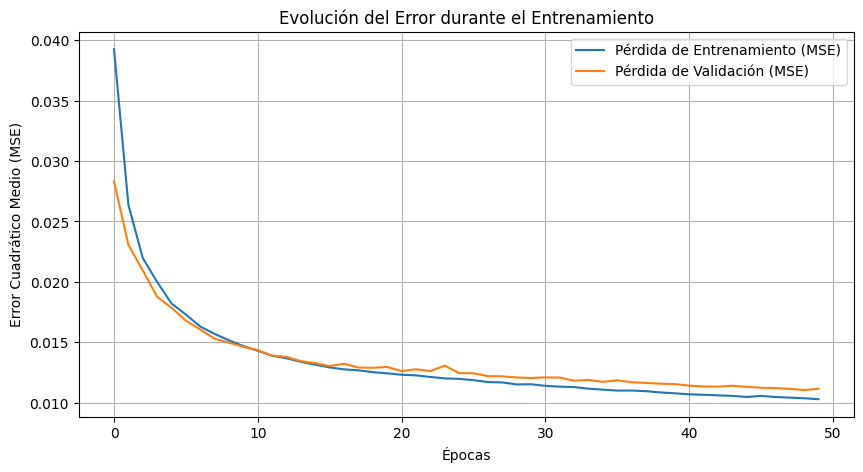

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


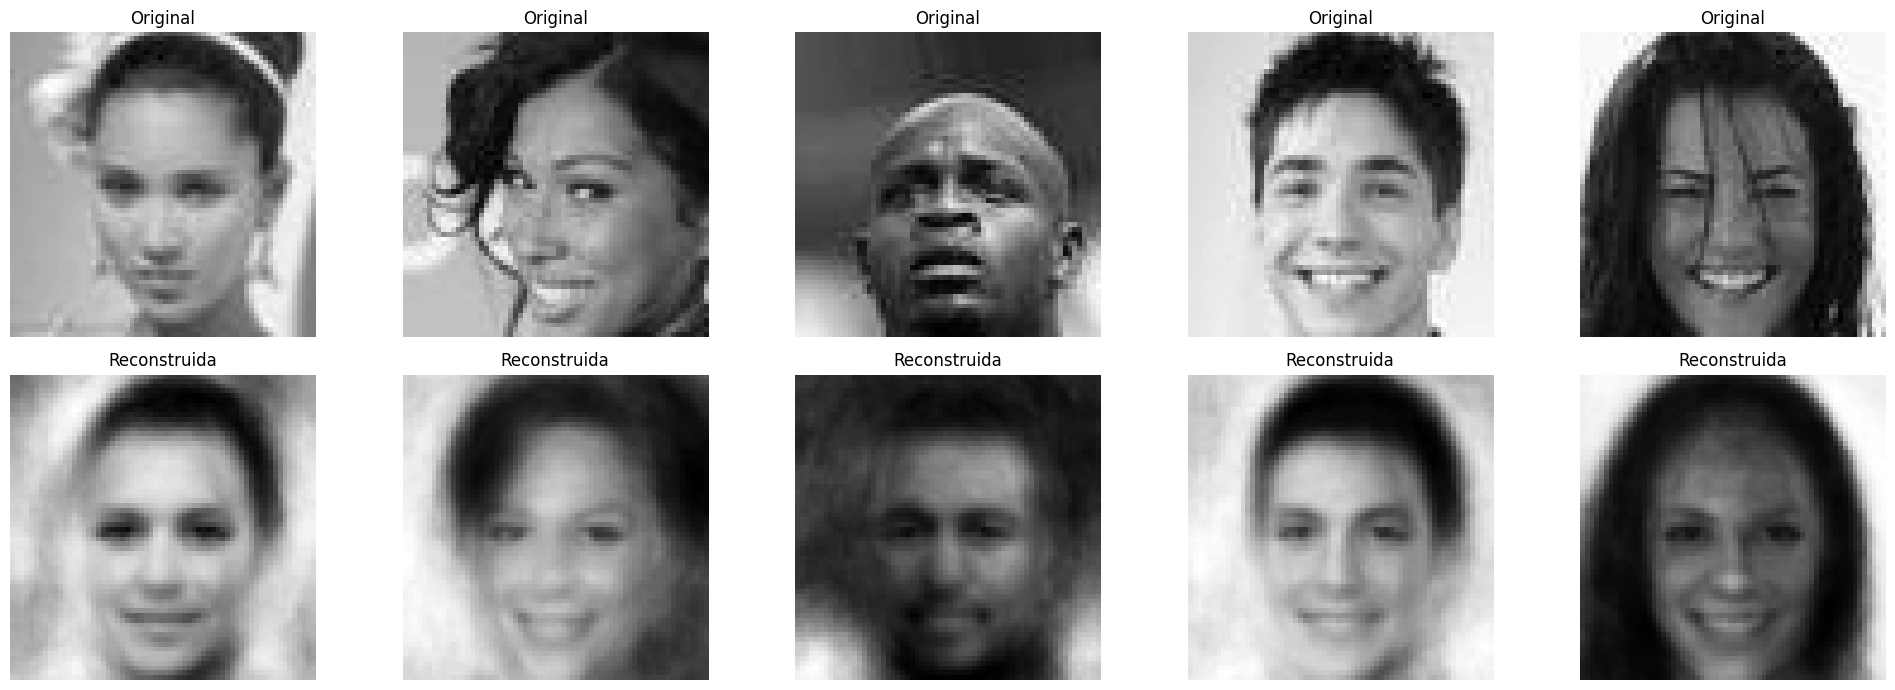

In [3]:
import matplotlib.pyplot as plt

# 1. Representación gráfica del historial de entrenamiento (Pérdida)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento (MSE)')
plt.plot(history.history['val_loss'], label='Pérdida de Validación (MSE)')
plt.title('Evolución del Error durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# 2. Representación visual de la reconstrucción de imágenes
n_images = 5 # Número de imágenes a mostrar
# Usaremos las primeras imágenes del dataset para la predicción
reconstructed_images = autoencoder_fc.predict(images_gray[:n_images])

plt.figure(figsize=(20, 7))
for i in range(n_images):
    # Imagen original
    ax = plt.subplot(2, n_images, i + 1)
    plt.imshow(images_gray[i].squeeze(), cmap='gray')
    ax.set_title("Original")
    plt.axis("off")
    
    # Imagen reconstruida
    ax = plt.subplot(2, n_images, i + 1 + n_images)
    plt.imshow(reconstructed_images[i].squeeze(), cmap='gray')
    ax.set_title("Reconstruida")
    plt.axis("off")
    
plt.tight_layout()
plt.show()

**E2:** Para obtener un *sparse autoencoder* y observar sus consecuencias en cuanto a codificación y reconstrucción, aplique una regularización de actividad L1 en la capa densa del espacio latente, así como activación ```ReLU```. Analice los resultados obtenidos en la codificación latente en comparación con los del ejercicio E1. Comente la diferencia observada en la reconstrucción y el espacio latente (calidad de reconstrucción, coeficientes no nulos obtenidos en el espacio latente, compresión efectiva de la codificación, etc.). *(Para reducción de cómputo puede utilizar las imágenes en escala de gris)*

In [4]:
from tensorflow.keras import regularizers


# ENCODER
encoder_input_sparse = layers.Input(shape=(64, 64, 1))
x = layers.Flatten()(encoder_input_sparse)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(128, activation="relu")(x)

# Solo cambia la capa del espacio latente respecto a E1:
latent_space_sparse = layers.Dense(
  latent_dim,
  activation="relu",
  activity_regularizer=regularizers.l1(10e-5) # Parámetro a ajustar
)(x)

# DECODER
x = layers.Dense(128, activation="relu")(latent_space_sparse)
x = layers.Dense(256, activation="relu")(x)
decoder_output_sparse = layers.Dense(input_dim, activation="sigmoid")(x)
decoder_output_sparse = layers.Reshape((64, 64, 1))(decoder_output_sparse)

# MODELO COMPLETO
autoencoder_sparse = models.Model(encoder_input_sparse, decoder_output_sparse, name="Autoencoder_Sparse")
autoencoder_sparse.compile(optimizer="adam", loss="mse")
autoencoder_sparse.summary()

history = autoencoder_sparse.fit(images_gray, images_gray, epochs=50, batch_size=32, validation_split=0.2)

Model: "Autoencoder_Sparse"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4096)           │     1,052,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 64, 64, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,364,160 (12.83 MB)

 Trainable params: 3,364,160 (12.83 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


I0000 00:00:1776853183.809847  137115 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_182835__.12


250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0658 - val_loss: 0.0632
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0639 - val_loss: 0.0633
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0639 - val_loss: 0.0631
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0639 - val_loss: 0.0631
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0639 - val_loss: 0.0631
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0639 - val_loss: 0.0631
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0638 - val_loss: 0.0634
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0638 - val_loss: 0.0633
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0638 - val_loss: 0.0631
Epoch 10/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0638 - val_loss: 0.0631
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0638 - val_loss: 0.0631
Epoch 12/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.

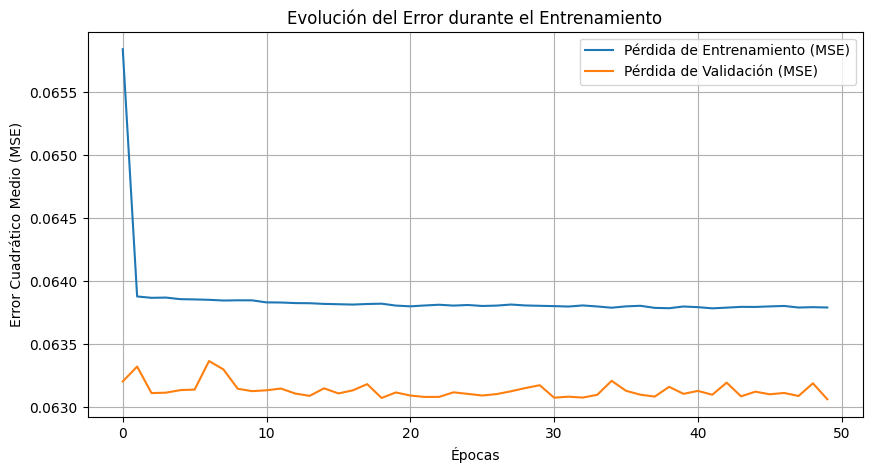

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


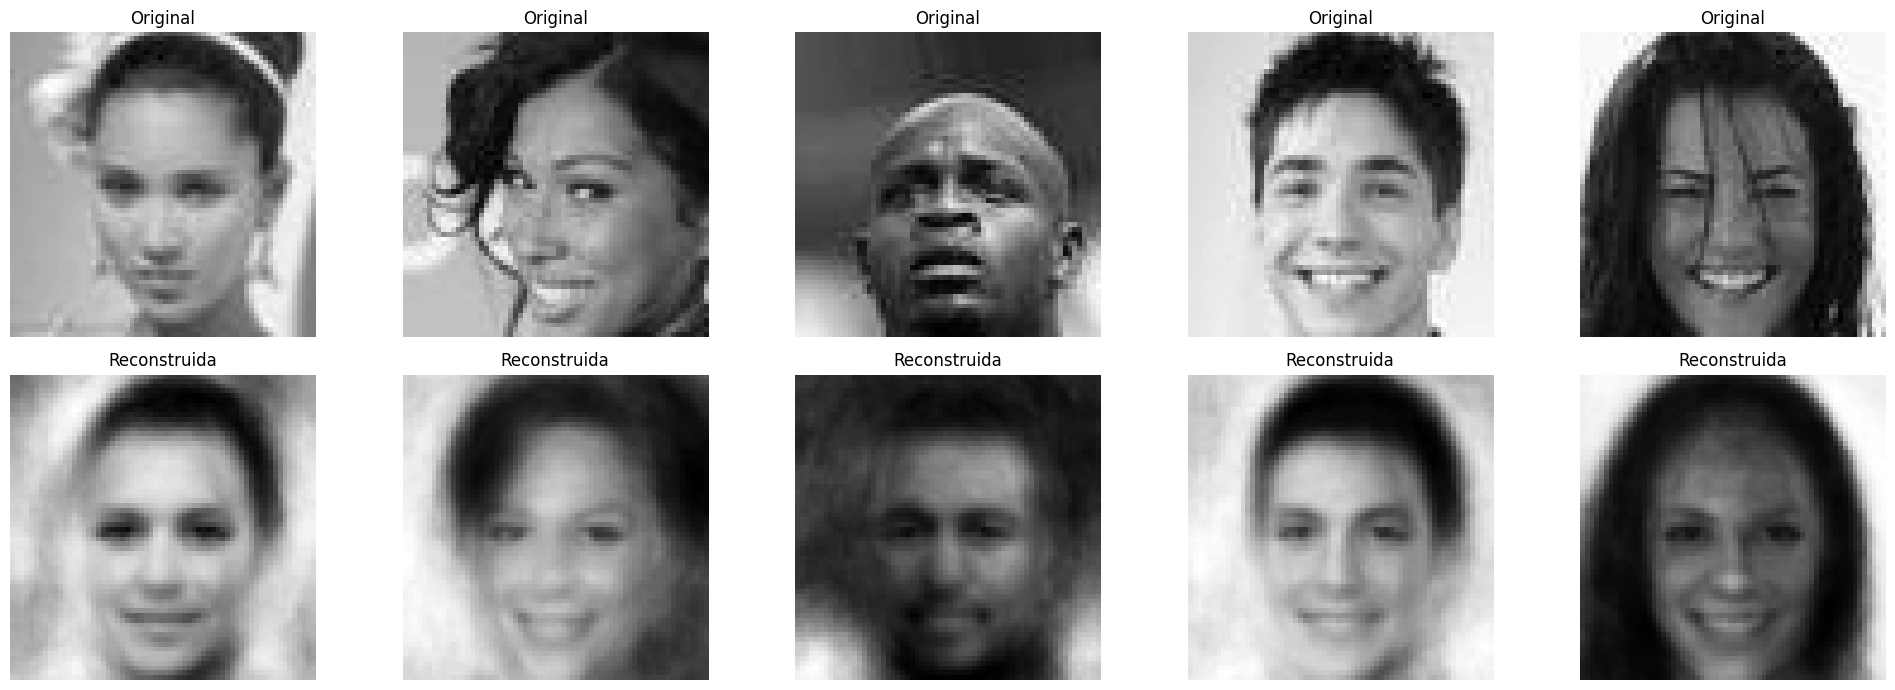

In [5]:
import matplotlib.pyplot as plt

# 1. Representación gráfica del historial de entrenamiento (Pérdida)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento (MSE)')
plt.plot(history.history['val_loss'], label='Pérdida de Validación (MSE)')
plt.title('Evolución del Error durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# 2. Representación visual de la reconstrucción de imágenes
n_images = 5 # Número de imágenes a mostrar
# Usaremos las primeras imágenes del dataset para la predicción
reconstructed_images = autoencoder_fc.predict(images_gray[:n_images])

plt.figure(figsize=(20, 7))
for i in range(n_images):
    # Imagen original
    ax = plt.subplot(2, n_images, i + 1)
    plt.imshow(images_gray[i].squeeze(), cmap='gray')
    ax.set_title("Original")
    plt.axis("off")
    
    # Imagen reconstruida
    ax = plt.subplot(2, n_images, i + 1 + n_images)
    plt.imshow(reconstructed_images[i].squeeze(), cmap='gray')
    ax.set_title("Reconstruida")
    plt.axis("off")
    
plt.tight_layout()
plt.show()

**E3:** A partir del código del ejercicio E1, diseñe ahora un *autoencoder* convolucional de 3 niveles de profundidad, utilizando capas convolucionales 2D de 16, 32 y 64 mapas de características, más el nivel correspondiente al espacio latente de dimensión 1024 (8 x 8 x 16), de acuerdo a lo comentado en el [apartado previo](#conv_autoencoder). Evite utilizar normalización de lotes en las capas de entrada y salida, así como en la correspondiente al espacio latente. Experimente con diferentes dimensiones del espacio latente en el *autoencoder* convolucional, por ejemplo 64, 256, 1024 y 4096, adaptando si es necesario la escalera de codificación-decodificación. Indique las diferencias en cuando a prestaciones con un *autoencoder* totalmente conectado (ejercicio E1): calidad de la reconstrucción conseguida, número de parámetros necesarios en el modelo, tiempo de entrenamiento, etc. *(Para reducción de cómputo puede utilizar las imágenes en escala de gris)*

In [6]:
# ENCODER
encoder_input_conv = layers.Input(shape=(64, 64, 1))

# Nivel 1
x = layers.Conv2D(16, kernel_size=3, strides=2, padding='same')(encoder_input_conv)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Nivel 2
x = layers.Conv2D(32, kernel_size=3, strides=2, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Nivel 3
x = layers.Conv2D(64, kernel_size=3, strides=2, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Espacio Latente (8x8x16 = 1024)
x = layers.Conv2D(16, kernel_size=3, strides=1, padding='same')(x)
latent_space_conv = layers.LeakyReLU()(x)

# DECODER
# Nivel 3 (Inverso)
x = layers.Conv2DTranspose(64, kernel_size=3, strides=1, padding='same')(latent_space_conv)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Nivel 2 (Inverso)
x = layers.Conv2DTranspose(32, kernel_size=3, strides=2, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Nivel 1 (Inverso)
x = layers.Conv2DTranspose(16, kernel_size=3, strides=2, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Salida
decoder_output_conv = layers.Conv2DTranspose(1, kernel_size=3, strides=2, padding='same', activation='sigmoid')(x)

autoencoder_conv = models.Model(encoder_input_conv, decoder_output_conv, name="Autoencoder_Conv")
autoencoder_conv.compile(optimizer='adam', loss='mse')
autoencoder_conv.summary()

history = autoencoder_conv.fit(images_gray, images_gray, epochs=50, batch_size=32, validation_split=0.2)

Model: "Autoencoder_Conv"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 16)       │         9,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 64)       │         9,280 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 65,937 (257.57 KB)

 Trainable params: 65,489 (255.82 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0119 - val_loss: 0.0256
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0044 - val_loss: 0.0037
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0035 - val_loss: 0.0029
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0030 - val_loss: 0.0030
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0027 - val_loss: 0.0023
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0026 - val_loss: 0.0024
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0025 - val_loss: 0.0019
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0023 - val_loss: 0.0019
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 10/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0021 - val_loss: 0.0017
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0020 - val_loss: 0.0016
Epoch 12/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

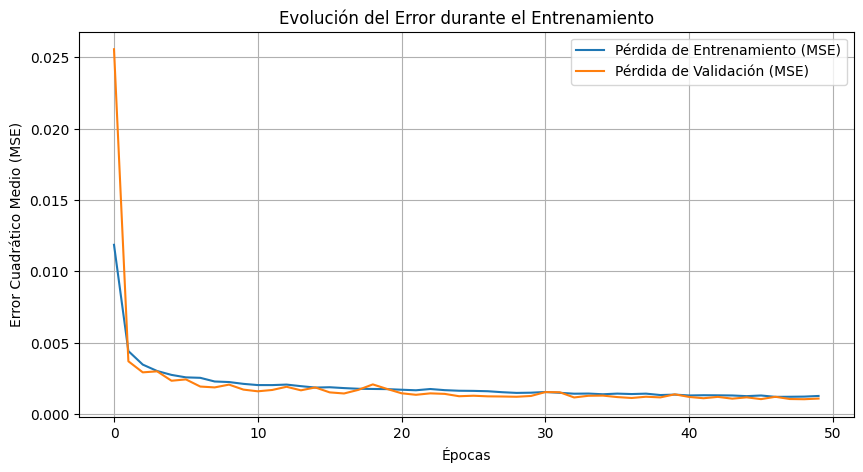

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 722ms/step


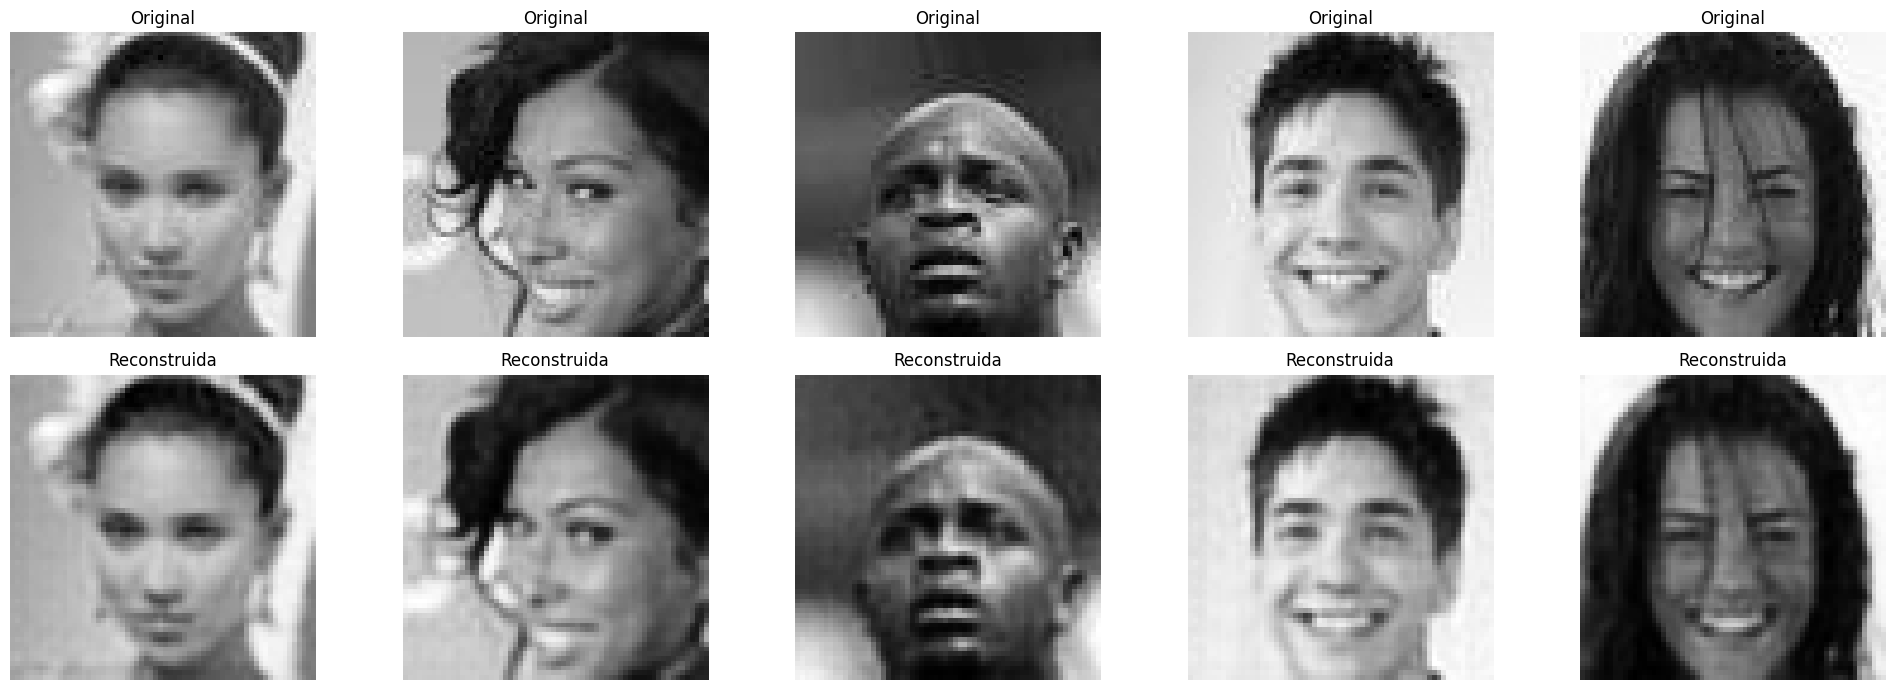

In [7]:
import matplotlib.pyplot as plt

# 1. Representación gráfica del historial de entrenamiento (Pérdida)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento (MSE)')
plt.plot(history.history['val_loss'], label='Pérdida de Validación (MSE)')
plt.title('Evolución del Error durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# 2. Representación visual de la reconstrucción de imágenes
n_images = 5 # Número de imágenes a mostrar
# Usaremos las primeras imágenes del dataset para la predicción
reconstructed_images = autoencoder_conv.predict(images_gray[:n_images])

plt.figure(figsize=(20, 7))
for i in range(n_images):
    # Imagen original
    ax = plt.subplot(2, n_images, i + 1)
    plt.imshow(images_gray[i].squeeze(), cmap='gray')
    ax.set_title("Original")
    plt.axis("off")
    
    # Imagen reconstruida
    ax = plt.subplot(2, n_images, i + 1 + n_images)
    plt.imshow(reconstructed_images[i].squeeze(), cmap='gray')
    ax.set_title("Reconstruida")
    plt.axis("off")
    
plt.tight_layout()
plt.show()

**E4:** Adapte el código del ejercicio E3 anterior para que funcione con las imágenes RGB en color cargadas del [dataset](#dataset). Experimente con el aumento del número de imágenes de dicho [dataset](#dataset) que se emplean para el entrenamiento, y comente de nuevo de diferencias observadas.

In [8]:
# ENCODER
encoder_input_conv = layers.Input(shape=(64, 64, 3))

# Nivel 1
x = layers.Conv2D(16, kernel_size=3, strides=2, padding='same')(encoder_input_conv)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Nivel 2
x = layers.Conv2D(32, kernel_size=3, strides=2, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Nivel 3
x = layers.Conv2D(64, kernel_size=3, strides=2, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Espacio Latente (8x8x16 = 1024)
x = layers.Conv2D(16, kernel_size=3, strides=1, padding='same')(x)
latent_space_conv = layers.LeakyReLU()(x)

# DECODER
# Nivel 3 (Inverso)
x = layers.Conv2DTranspose(64, kernel_size=3, strides=1, padding='same')(latent_space_conv)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Nivel 2 (Inverso)
x = layers.Conv2DTranspose(32, kernel_size=3, strides=2, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Nivel 1 (Inverso)
x = layers.Conv2DTranspose(16, kernel_size=3, strides=2, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Salida
decoder_output_conv = layers.Conv2DTranspose(3, kernel_size=3, strides=2, padding='same', activation='sigmoid')(x)

autoencoder_conv = models.Model(encoder_input_conv, decoder_output_conv, name="Autoencoder_Conv_RGB")
autoencoder_conv.compile(optimizer='adam', loss='mse')
autoencoder_conv.summary()

history = autoencoder_conv.fit(images, images, epochs=50, batch_size=32, validation_split=0.2)

Model: "Autoencoder_Conv_RGB"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 16)       │         9,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 8, 8, 64)       │         9,280 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 16, 16, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 32, 32, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 66,515 (259.82 KB)

 Trainable params: 66,067 (258.07 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0181 - val_loss: 0.0162
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0059 - val_loss: 0.0072
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0048 - val_loss: 0.0050
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0043 - val_loss: 0.0038
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0038 - val_loss: 0.0038
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0035 - val_loss: 0.0029
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0034 - val_loss: 0.0031
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0032 - val_loss: 0.0028
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0029 - val_loss: 0.0026
Epoch 10/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0029 - val_loss: 0.0025
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0029 - val_loss: 0.0027
Epoch 12/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

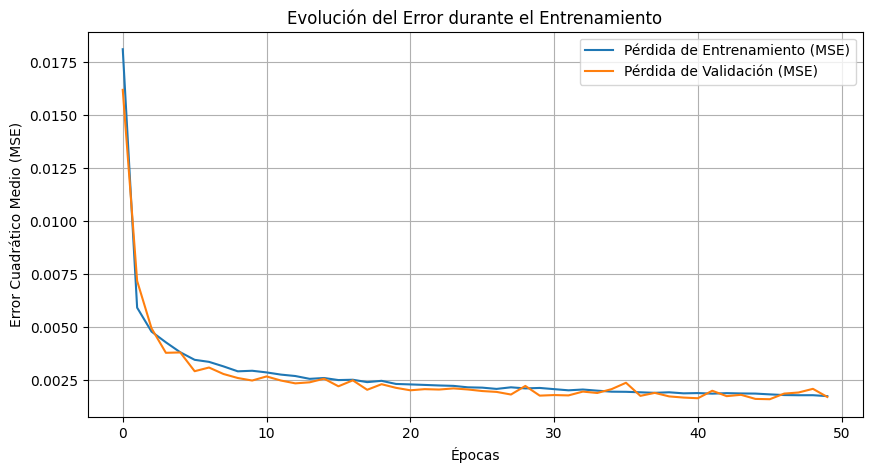

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step


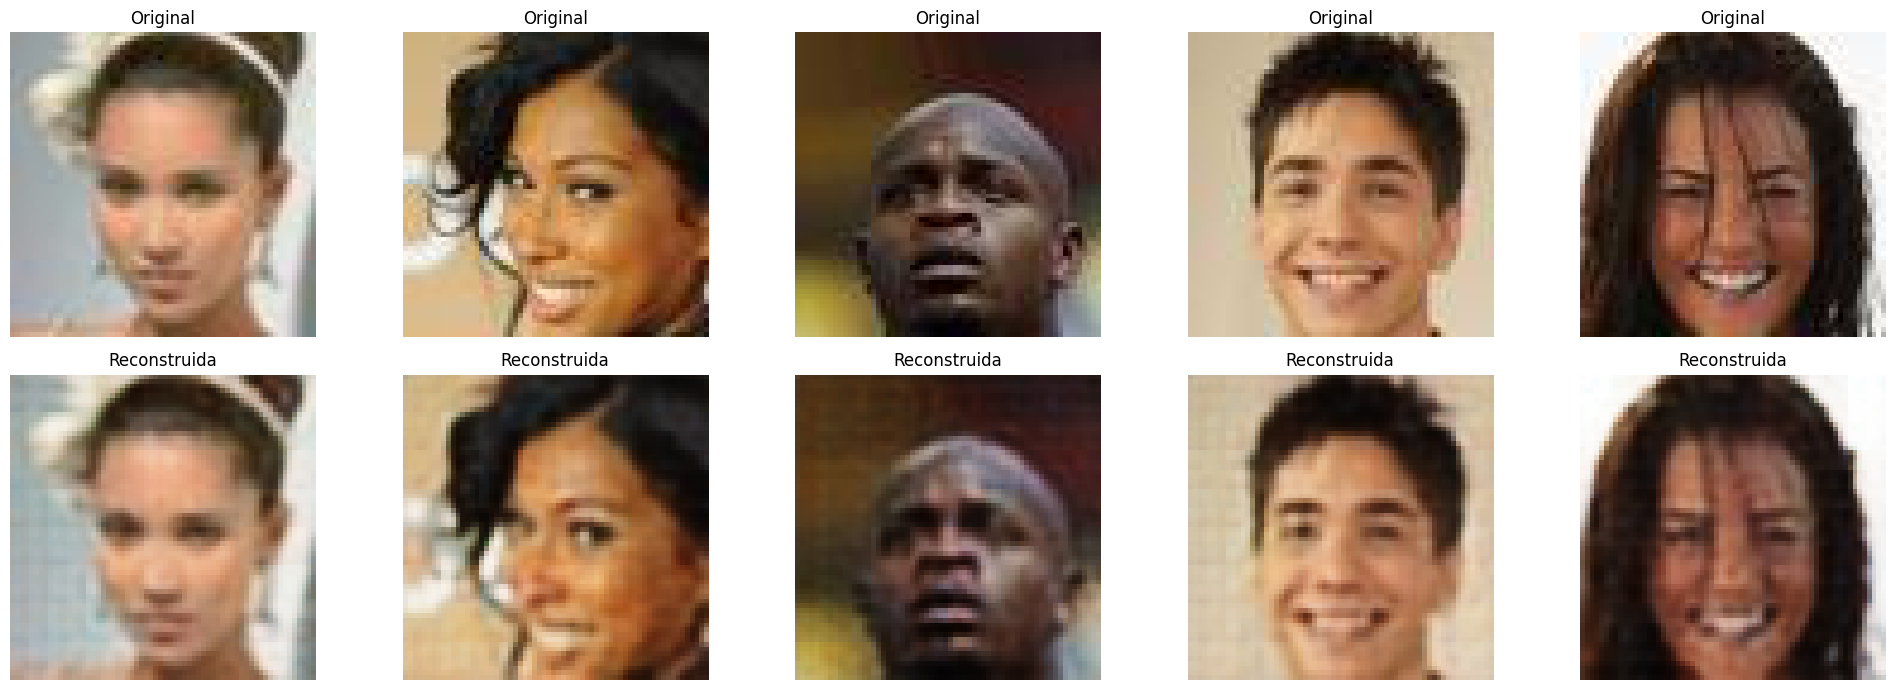

In [9]:
import matplotlib.pyplot as plt

# 1. Representación gráfica del historial de entrenamiento (Pérdida)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento (MSE)')
plt.plot(history.history['val_loss'], label='Pérdida de Validación (MSE)')
plt.title('Evolución del Error durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# 2. Representación visual de la reconstrucción de imágenes
n_images = 5 # Número de imágenes a mostrar
# Usaremos las primeras imágenes del dataset para la predicción
reconstructed_images = autoencoder_conv.predict(images[:n_images])

plt.figure(figsize=(20, 7))
for i in range(n_images):
    # Imagen original
    ax = plt.subplot(2, n_images, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title("Original")
    plt.axis("off")
    
    # Imagen reconstruida
    ax = plt.subplot(2, n_images, i + 1 + n_images)
    plt.imshow(reconstructed_images[i].squeeze())
    ax.set_title("Reconstruida")
    plt.axis("off")
    
plt.tight_layout()
plt.show()

**E5:** Adepte el código de los ejercicios E3/E4 para que obtener una variante de *autoencoder* convolucional capaz colorear imágenes de nivel de gris. Para ello se tomarán como entradas las imágenes de nivel de gris y como salida las imágenes en color.

In [ ]:
# ENCODER
encoder_input_conv = layers.Input(shape=(64, 64, 1))

# Nivel 1
x = layers.Conv2D(16, kernel_size=3, strides=2, padding='same')(encoder_input_conv)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Nivel 2
x = layers.Conv2D(32, kernel_size=3, strides=2, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Nivel 3
x = layers.Conv2D(64, kernel_size=3, strides=2, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Espacio Latente (8x8x16 = 1024)
x = layers.Conv2D(16, kernel_size=3, strides=1, padding='same')(x)
latent_space_conv = layers.LeakyReLU()(x)

# DECODER
# Nivel 3 (Inverso)
x = layers.Conv2DTranspose(64, kernel_size=3, strides=1, padding='same')(latent_space_conv)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Nivel 2 (Inverso)
x = layers.Conv2DTranspose(32, kernel_size=3, strides=2, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Nivel 1 (Inverso)
x = layers.Conv2DTranspose(16, kernel_size=3, strides=2, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Salida
decoder_output_conv = layers.Conv2DTranspose(3, kernel_size=3, strides=2, padding='same', activation='sigmoid')(x)

autoencoder_conv = models.Model(encoder_input_conv, decoder_output_conv, name="Autoencoder_Conv_RGB")
autoencoder_conv.compile(optimizer='adam', loss='mse')
autoencoder_conv.summary()

history = autoencoder_conv.fit(images_gray, images, epochs=50, batch_size=32, validation_split=0.2)

Model: "Autoencoder_Conv_RGB"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 16)       │         9,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 8, 8, 64)       │         9,280 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_18 (LeakyReLU)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 16, 16, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_19 (LeakyReLU)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_10             │ (None, 32, 32, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 66,227 (258.70 KB)

 Trainable params: 65,779 (256.95 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0204 - val_loss: 0.0281
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0082 - val_loss: 0.0076
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0072 - val_loss: 0.0073
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0067 - val_loss: 0.0063
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0064 - val_loss: 0.0068
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0062 - val_loss: 0.0058
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0061 - val_loss: 0.0065
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0059 - val_loss: 0.0064
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0058 - val_loss: 0.0056
Epoch 10/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0057 - val_loss: 0.0059
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0056 - val_loss: 0.0065
Epoch 12/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

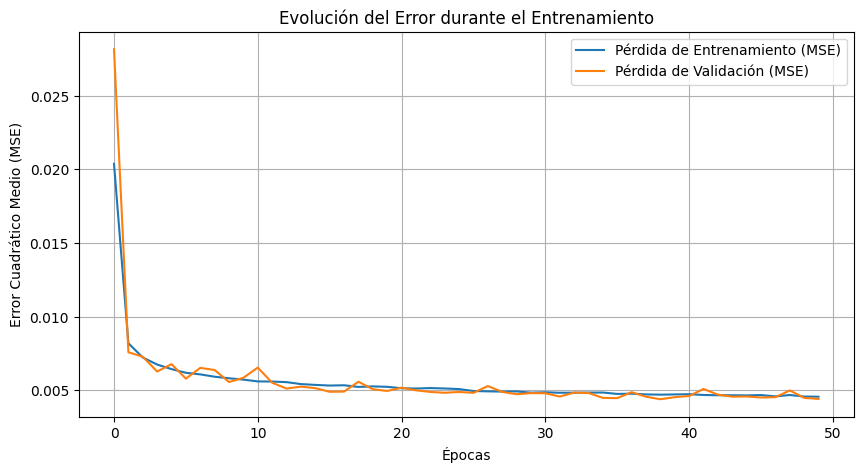

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


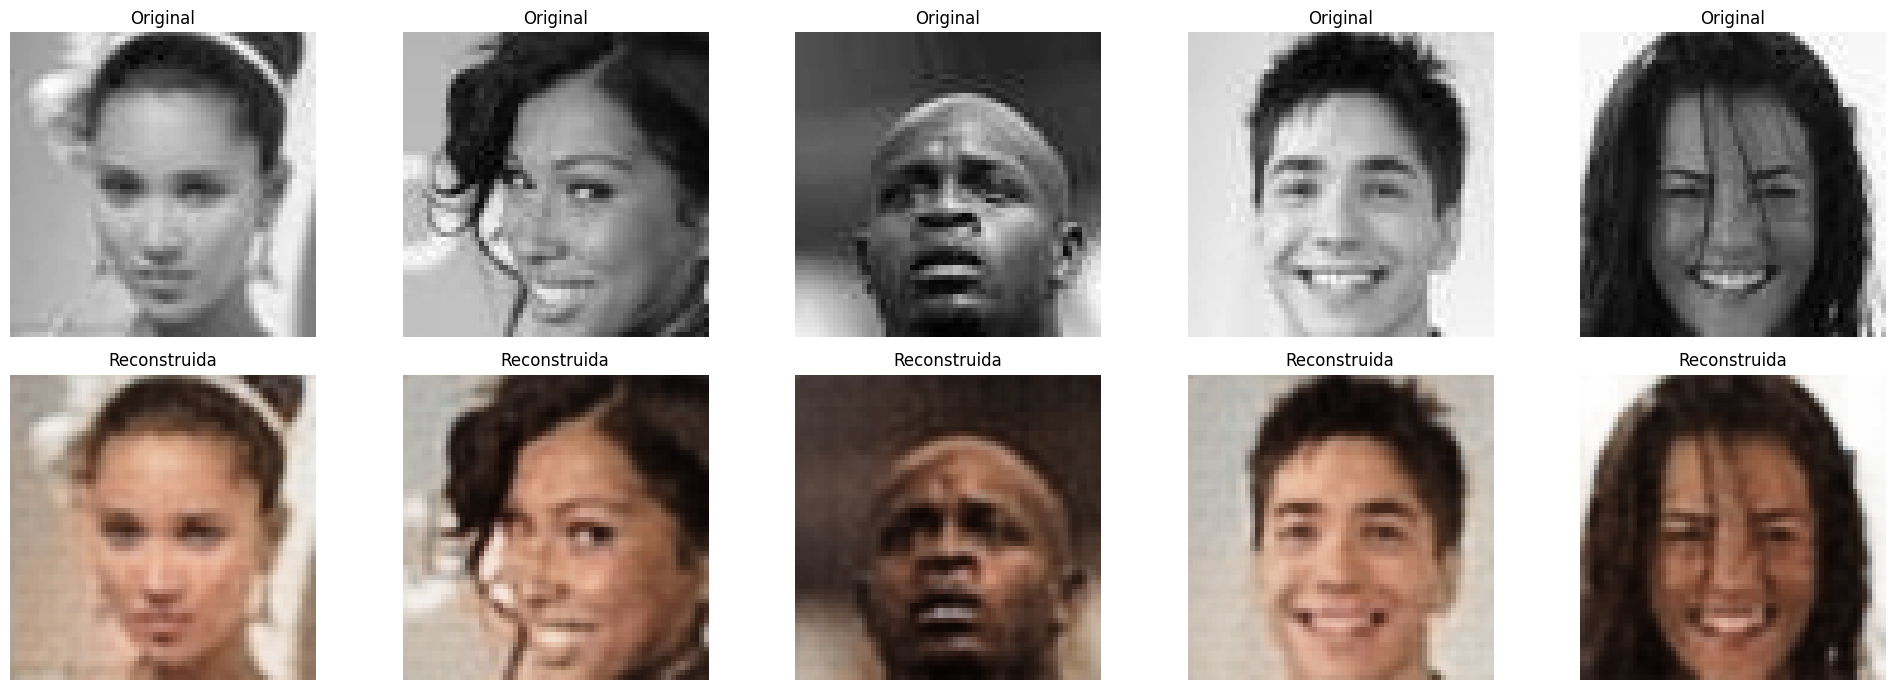

In [12]:
import matplotlib.pyplot as plt

# 1. Representación gráfica del historial de entrenamiento (Pérdida)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento (MSE)')
plt.plot(history.history['val_loss'], label='Pérdida de Validación (MSE)')
plt.title('Evolución del Error durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# 2. Representación visual de la reconstrucción de imágenes
n_images = 5 # Número de imágenes a mostrar
# Usaremos las primeras imágenes del dataset para la predicción
reconstructed_images = autoencoder_conv.predict(images_gray[:n_images])

plt.figure(figsize=(20, 7))
for i in range(n_images):
    # Imagen original
    ax = plt.subplot(2, n_images, i + 1)
    plt.imshow(images_gray[i].squeeze(), cmap='gray')
    ax.set_title("Original")
    plt.axis("off")
    
    # Imagen reconstruida
    ax = plt.subplot(2, n_images, i + 1 + n_images)
    plt.imshow(reconstructed_images[i].squeeze())
    ax.set_title("Reconstruida")
    plt.axis("off")
    
plt.tight_layout()
plt.show()